In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional, Conv1D, MaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from google.colab import drive
import os
# Mount Google Drive
drive.mount('/content/drive')

# Initialize NLTK
nltk.download(['stopwords', 'wordnet', 'omw-1.4'])
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Data Loading

In [2]:
# UPDATE THIS PATH to your folder in Google Drive
path_prefix = '/content/drive/MyDrive/datasets/emotion_data/'

def load_data(file_name):
    return pd.read_csv(path_prefix + file_name, names=['Text', 'Emotion'], sep=';')

try:
    train = load_data('train.txt')
    val = load_data('val.txt')
    test = load_data('test.txt')
    print(f"Shapes: Train {train.shape}, Val {val.shape}, Test {test.shape}")
except FileNotFoundError:
    print("Error: Check your path_prefix and ensure the files are in that Google Drive folder.")

Shapes: Train (16000, 2), Val (2000, 2), Test (2000, 2)


Quick EDA

/tmp/ipython-input-405/2924628459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Emotion', data=train, palette='magma', order=train['Emotion'].value_counts().index)


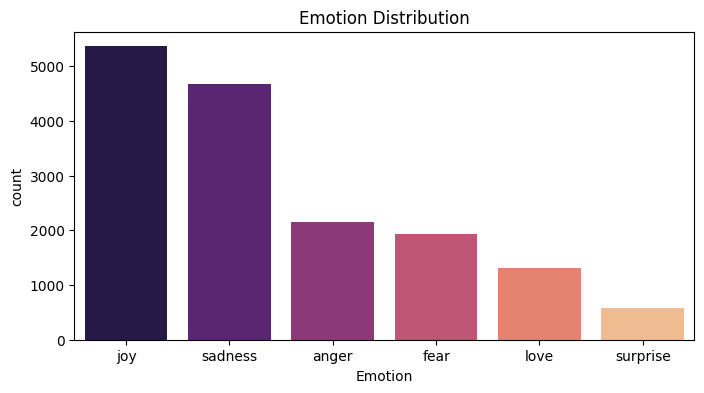

In [3]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Emotion', data=train, palette='magma', order=train['Emotion'].value_counts().index)
plt.title('Emotion Distribution')
plt.show()

Text Cleaning Function

In [4]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

train['Clean_Text'] = train['Text'].apply(clean_text)
val['Clean_Text'] = val['Text'].apply(clean_text)
test['Clean_Text'] = test['Text'].apply(clean_text)

Tokenization & Padding

In [5]:
MAX_LEN = 229
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train['Clean_Text'])
vocab_size = len(tokenizer.word_index) + 1

X_train = pad_sequences(tokenizer.texts_to_sequences(train['Clean_Text']), maxlen=MAX_LEN)
X_val = pad_sequences(tokenizer.texts_to_sequences(val['Clean_Text']), maxlen=MAX_LEN)
X_test = pad_sequences(tokenizer.texts_to_sequences(test['Clean_Text']), maxlen=MAX_LEN)

Label Encoding

In [6]:
le = LabelEncoder()
y_train = le.fit_transform(train['Emotion'])
y_val = le.transform(val['Emotion'])
y_test = le.transform(test['Emotion'])

num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


CNN + BiLSTM Model Construction

In [7]:
model = Sequential([
    Embedding(vocab_size, 100, input_length=MAX_LEN),
    # CNN Layer for feature extraction
    Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    # BiLSTM Layer for sequential learning
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model Training

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 123s 441ms/step - accuracy: 0.3577 - loss: 1.5225 - val_accuracy: 0.8265 - val_loss: 0.5246
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.8715 - loss: 0.3818 - val_accuracy: 0.8805 - val_loss: 0.3119
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 433ms/step - accuracy: 0.9330 - loss: 0.1989 - val_accuracy: 0.9055 - val_loss: 0.3091
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 438ms/step - accuracy: 0.9539 - loss: 0.1314 - val_accuracy: 0.9025 - val_loss: 0.3280
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.9642 - loss: 0.1032 - val_accuracy: 0.9025 - val_loss: 0.3344
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 109s 436ms/step - accuracy: 0.9771 - loss: 0.0688 - val_accuracy: 0.9025 - val_loss: 0.3622


Performance Evaluation

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.9033 - loss: 0.3224
Test Accuracy: 0.9040


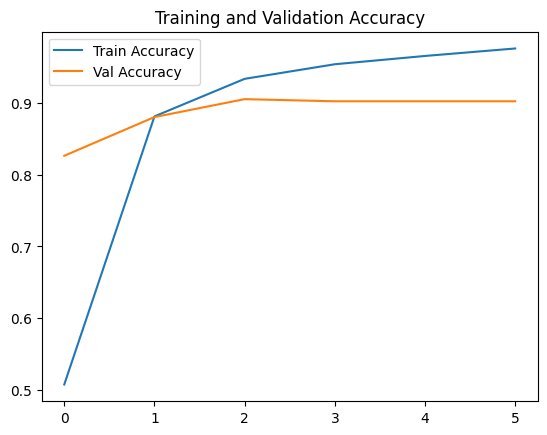

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Plotting Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [10]:
# Metrics table (run after training)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

# Overall metrics summary table
metrics_data = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Precision (weighted)',
               'Recall (macro)', 'Recall (weighted)',
               'F1 (macro)', 'F1 (weighted)'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='macro', zero_division=0),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='macro', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
    ]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df['Score'] = metrics_df['Score'].round(4)
print('Overall test-set metrics')
display(metrics_df)

# Per-class metrics table
report = classification_report(
    y_test, y_pred, target_names=le.classes_,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).T
report_df = report_df.round(4)
# Drop 'accuracy', 'macro avg', 'weighted avg' from index for per-class table
per_class = report_df.loc[le.classes_]
print('\nPer-class metrics (precision, recall, f1-score)')
display(per_class)

Overall test-set metrics


,Metric,Score
0,Accuracy,0.9040
1,Precision (macro),0.8344
2,Precision (weighted),0.9058
3,Recall (macro),0.8447
4,Recall (weighted),0.9040
5,F1 (macro),0.8391
6,F1 (weighted),0.9047



Per-class metrics (precision, recall, f1-score)


,precision,recall,f1-score,support
anger,0.9055,0.9055,0.9055,275.0
fear,0.8773,0.8616,0.8694,224.0
joy,0.9441,0.9237,0.9338,695.0
love,0.7557,0.8365,0.7940,159.0
sadness,0.9501,0.9501,0.9501,581.0
surprise,0.5735,0.5909,0.5821,66.0


Inference/Prediction Function

In [11]:
def predict_emotion(sentence):
    cleaned = clean_text(sentence)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN)

    pred = model.predict(padded)
    result = le.inverse_transform([np.argmax(pred)])[0]
    confidence = np.max(pred)

    print(f"Input: {sentence}")
    print(f"Result: {result} ({confidence:.2f})")

# Sample Prediction
predict_emotion("i am angry on you ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Input: i am angry on you 
Result: anger (0.64)


### Model Inference

This section demonstrates how to load the saved model and use it to predict emotions for new text inputs. Please ensure that previous cells defining `tokenizer`, `MAX_LEN`, and `le` (LabelEncoder) have been executed, as these are crucial for preprocessing new text and decoding predictions.

In [12]:
import tensorflow as tf
import numpy as np
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os # Import os module

# Ensure NLTK data is downloaded and components are initialized
nltk.download(['stopwords', 'wordnet', 'omw-1.4'], quiet=True)
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Define the clean_text function (re-defined here for self-containment of the inference cell)
def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

# Define the path to the saved model
save_path = '/content/drive/MyDrive/models/emotion_model' # Corrected path
model_path = f'{save_path}/emotion_cnn_bilstm_model.keras'

# Check if the model file exists before attempting to load
if not os.path.exists(model_path):
    print(f"Error: Model file not found at {model_path}. Please ensure the model was saved correctly and the path is accurate.")
    loaded_model = None
else:
    # Load the saved model
    try:
        loaded_model = tf.keras.models.load_model(model_path)
        print("Model loaded successfully!")
    except Exception as e:
        print(f"Error loading model: {e}")
        loaded_model = None

# Assuming tokenizer, MAX_LEN, and le are available from previous cell executions.
# If running this cell in a fresh environment, tokenizer and le would need to be reloaded/re-initialized.
# For example, they could be saved using pickle and loaded here.

# Function to predict emotion using the loaded model
def predict_emotion_with_loaded_model(sentence, model_to_use, tokenizer_obj, max_len_obj, label_encoder_obj):
    if model_to_use is None:
        print("Model is not loaded. Cannot make prediction.")
        return

    cleaned = clean_text(sentence)
    seq = tokenizer_obj.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len_obj)

    pred = model_to_use.predict(padded, verbose=0)
    result = label_encoder_obj.inverse_transform([np.argmax(pred)])[0]
    confidence = np.max(pred)

    print(f"Input: {sentence}")
    print(f"Result: {result} (confidence: {confidence:.2f})")

# Sample Prediction using the loaded model and existing tokenizer, MAX_LEN, and le
if loaded_model is not None:
    predict_emotion_with_loaded_model("i am feeling so happy right now", loaded_model, tokenizer, MAX_LEN, le)
    predict_emotion_with_loaded_model("i hate this situation, it makes me angry", loaded_model, tokenizer, MAX_LEN, le)
else:
    print("Cannot perform sample predictions as the model failed to load.")

Error: Model file not found at /content/drive/MyDrive/models/emotion_model/emotion_cnn_bilstm_model.keras. Please ensure the model was saved correctly and the path is accurate.
Cannot perform sample predictions as the model failed to load.


In [13]:
import os

# Define the path to the saved model directory
save_path = '/content/drive/MyDrive/models/emotion_model' # Corrected path

print(f"Listing contents of: {save_path}")

if os.path.exists(save_path):
    # List all files and directories in the specified path
    for item in os.listdir(save_path):
        print(item)
else:
    print(f"Error: Directory not found at {save_path}. Please check the path and ensure Google Drive is mounted correctly.")

Listing contents of: /content/drive/MyDrive/models/emotion_model
Error: Directory not found at /content/drive/MyDrive/models/emotion_model. Please check the path and ensure Google Drive is mounted correctly.


In [14]:
import os

# Define the path to save the model in Google Drive
save_path = '/content/drive/MyDrive/models/emotion_model' # Corrected 'modles' to 'models'

# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save the model
model.save(f'{save_path}/emotion_cnn_bilstm_model.keras') # Keras native format (recommended)

print(f"Model saved successfully to: {save_path}/emotion_cnn_bilstm_model.keras")

Model saved successfully to: /content/drive/MyDrive/models/emotion_model/emotion_cnn_bilstm_model.keras
